In [1]:
import numpy as np
import torch
import os

from pydose_rt.data import Patient, MachineConfig, BeamSequence
from pydose_rt import DoseEngine

In [13]:
machine_config = MachineConfig(
    preset="/home/sglatz54/projects/autoplan_2/PyDoseRT/src/pydose_rt/data/machine_presets/vienna_10MV.json",
    profile_corrections=None,  # TODO: add profile corrections
    output_factors=None,
    head_scatter_amplitude=None,
    head_scatter_sigma=None,
    mlc_transmission=0.0
    )
number_of_beams = 180
gantry_angles = torch.from_numpy(np.linspace(-180, 180, number_of_beams, endpoint=False))
field_size = (400, 400)
iso_center = (200.0, 200.0, 200.0)
collimator_angles = torch.from_numpy(np.array([0.0 for _ in range(number_of_beams)]))
sid = 1000.0
open_field_size = 0.0
kernel_size = 15
device = torch.device("cuda")
dtype = torch.float16
resolution = (1.25, 3.125, 3.125)
image_shape = (320, 128, 128)

beam_sequence = BeamSequence.create(gantry_angles,
                                    machine_config.number_of_leaf_pairs,
                                    field_size,
                                    iso_center,
                                    collimator_angles,
                                    sid,
                                    open_field_size,
                                    device,
                                    dtype,
                                    True    
)

engine = DoseEngine(
    machine_config=machine_config,
    dose_grid_spacing=resolution,
    dose_grid_shape=image_shape,
    beam_template=beam_sequence,
    kernel_size=kernel_size, 
    adjust_values=False,
    dtype=dtype, 
    device=device
)

engine.calibrate(
    calibration_mu=machine_config.calibration_mu,
    original_beam_template=beam_sequence
)

Calibration failed. Adjusting calibration factor to: 0.0027215181630550664


/home/sglatz54/projects/autoplan_2/PyDoseRT/src/pydose_rt/geometry/projections.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  leaf_widths = torch.tensor(


In [14]:
from pydose_rt.physics.attenuation.hu_density_conversion import convert_HU_to_density


path = "/home/sglatz54/projects/rt_ai_preprocesssing/tests/example_data/processed_small/"

for pat in os.listdir(path)[0:1]:
    # hotfix
    path = "/home/sglatz54/projects/rt_ai_preprocesssing/tests/example_data/processed_old/"
    pat = "MrAlderson_test_loc_large_1"
    print(f"Processing patient: {pat}")
    ct = np.load(os.path.join(path, pat, "CT.npy"), allow_pickle=True)
    dose = np.load(os.path.join(path, pat, "Dose.npy"), allow_pickle=True)
    plan = np.load(os.path.join(path, pat, "Beam.npy"), allow_pickle=True).item()

    ct = torch.from_numpy(ct).to(device).unsqueeze(0).to(torch.float16)
    ct = convert_HU_to_density(ct)

    leaves = torch.from_numpy(plan["POS"]).to(device).unsqueeze(0)
    jaws = torch.from_numpy(plan["ASYM"]).to(device).unsqueeze(0)
    metersets = torch.from_numpy(plan["METERSET"]).to(device).unsqueeze(0)

    leaves = leaves.squeeze(-1)
    leaves = leaves.permute(0, 2, 3, 1)
    leaves = leaves.flip(1)

    mus = metersets.squeeze(dim=(1, 3, 4))
    mus = mus.flip(1)

    jaws = jaws.squeeze(dim=(3, 4))
    jaws = jaws.permute(0, 2, 1)
    jaws = jaws.flip(1)

    leaves, jaws, mus = (
        leaves.to(torch.float16),
        jaws.to(torch.float16),
        mus.to(torch.float16),
    )  # Dose engine needs float16

    dose_pred = engine.forward(
        leaves,
        mus,
        jaws,
        ct,
    ).to(torch.float32)

Processing patient: MrAlderson_test_loc_large_1


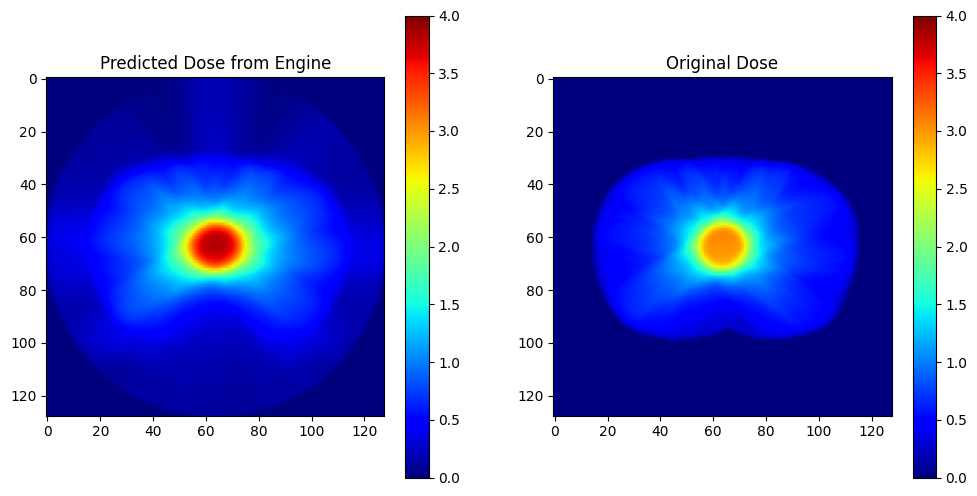

In [15]:
# Plot dose from engine and original dose
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(dose_pred[0, dose_pred.shape[1] // 2].cpu(), cmap="jet", vmin=0, vmax=4)
plt.title("Predicted Dose from Engine")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(dose[dose.shape[0] // 2], cmap="jet", vmin=0, vmax=4)
plt.title("Original Dose")
plt.colorbar()
plt.show()

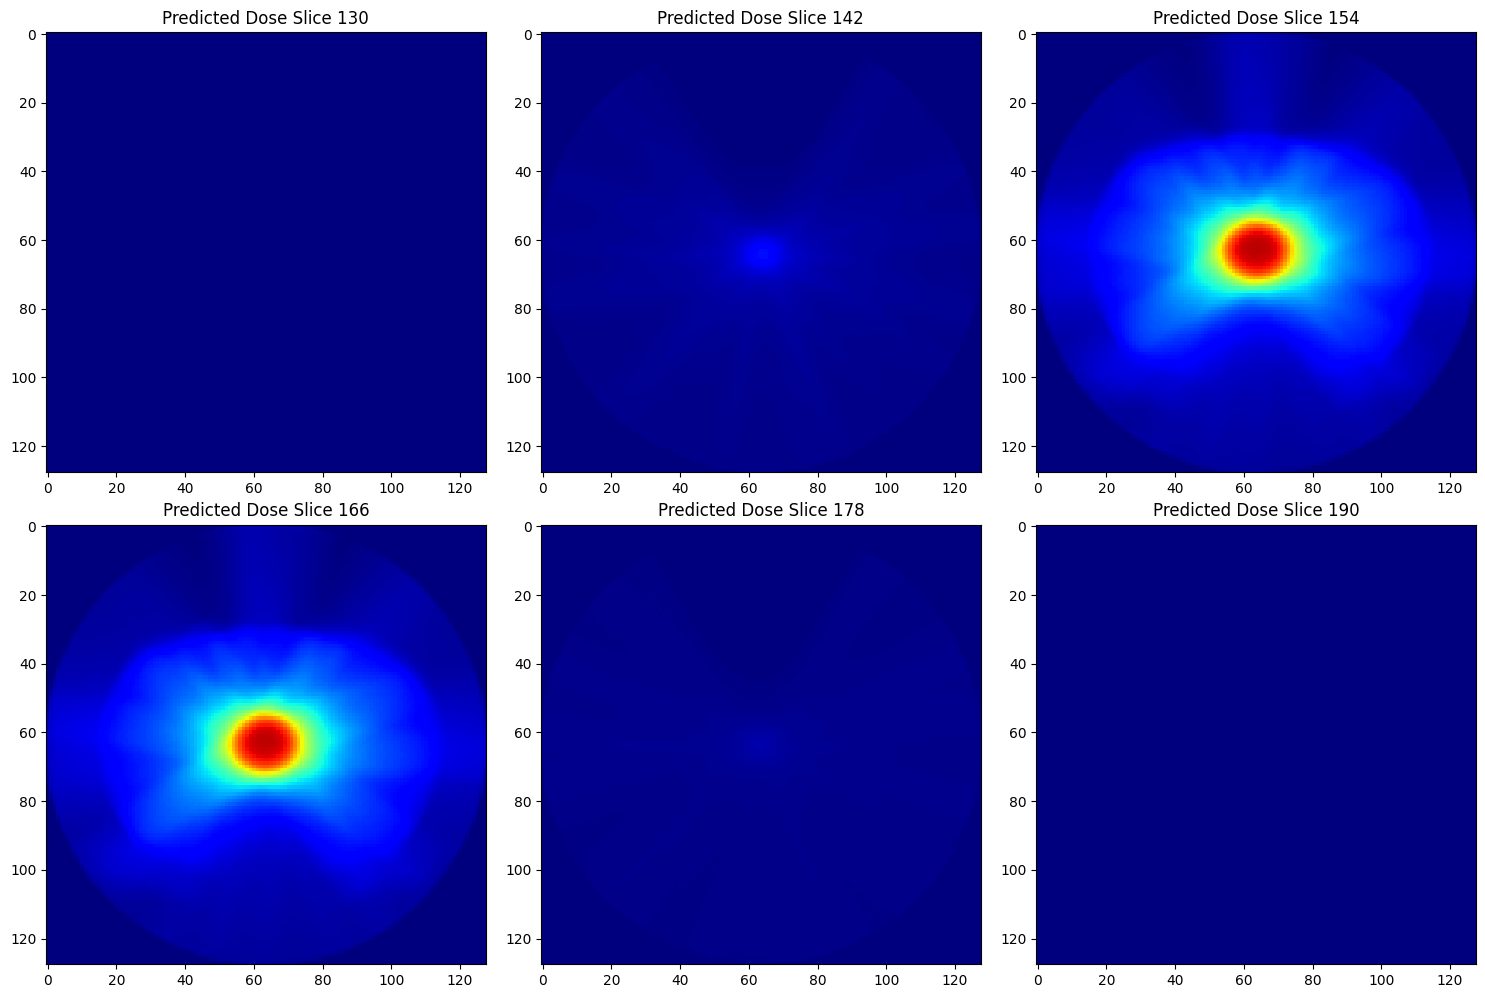

In [16]:
# Plot 6 slices of the predicted dose from 130 to 190

plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    slice_idx = 130 + i * (190 - 130) // 5
    plt.imshow(dose_pred[0, slice_idx].cpu(), cmap="jet", vmin=0, vmax=4)
    plt.title(f"Predicted Dose Slice {slice_idx}")

plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------

In [17]:
machine_config = MachineConfig(
    preset="/home/sglatz54/projects/autoplan_2/PyDoseRT/src/pydose_rt/data/machine_presets/vienna_10MV.json",
    profile_corrections=None,  # TODO: add profile corrections
    output_factors=None,
    head_scatter_amplitude=None,
    head_scatter_sigma=None,
    mlc_transmission=0.0
    )
number_of_beams = 180
gantry_angles = torch.from_numpy(np.linspace(-180, 180, number_of_beams, endpoint=False))
field_size = (400, 400)
iso_center = (200.0, 200.0, 200.0)
collimator_angles = torch.from_numpy(np.array([0.0 for _ in range(number_of_beams)]))
sid = 1000.0
open_field_size = 0.0
kernel_size = 15
device = torch.device("cuda")
dtype = torch.float16
resolution = (3.125, 3.125, 3.125)
image_shape = (128, 128, 128)

beam_sequence = BeamSequence.create(gantry_angles,
                                    machine_config.number_of_leaf_pairs,
                                    field_size,
                                    iso_center,
                                    collimator_angles,
                                    sid,
                                    open_field_size,
                                    device,
                                    dtype,
                                    True    
)

engine = DoseEngine(
    machine_config=machine_config,
    dose_grid_spacing=resolution,
    dose_grid_shape=image_shape,
    beam_template=beam_sequence,
    kernel_size=kernel_size, 
    adjust_values=False,
    dtype=dtype, 
    device=device
)

engine.calibrate(
    calibration_mu=machine_config.calibration_mu,
    original_beam_template=beam_sequence
)

Calibration failed. Adjusting calibration factor to: 0.004183223763983752


In [19]:
from pydose_rt.physics.attenuation.hu_density_conversion import convert_HU_to_density


path = "/home/sglatz54/projects/rt_ai_preprocesssing/tests/example_data/processed_small/"

for pat in os.listdir(path)[0:1]:
    # hotfix
    path = "/home/sglatz54/projects/rt_ai_preprocesssing/tests/example_data/processed_old/"
    pat = "MrAlderson_test_loc_small_1"
    print(f"Processing patient: {pat}")
    ct = np.load(os.path.join(path, pat, "CT.npy"), allow_pickle=True)
    dose = np.load(os.path.join(path, pat, "Dose.npy"), allow_pickle=True)
    plan = np.load(os.path.join(path, pat, "Beam.npy"), allow_pickle=True).item()

    ct = torch.from_numpy(ct).to(device).unsqueeze(0).to(torch.float16)
    ct = convert_HU_to_density(ct)

    leaves = torch.from_numpy(plan["POS"]).to(device).unsqueeze(0)
    jaws = torch.from_numpy(plan["ASYM"]).to(device).unsqueeze(0)
    metersets = torch.from_numpy(plan["METERSET"]).to(device).unsqueeze(0)

    leaves = leaves.squeeze(-1)
    leaves = leaves.permute(0, 2, 3, 1)
    leaves = leaves.flip(1)

    mus = metersets.squeeze(dim=(1, 3, 4))
    mus = mus.flip(1)

    jaws = jaws.squeeze(dim=(3, 4))
    jaws = jaws.permute(0, 2, 1)
    jaws = jaws.flip(1)

    leaves, jaws, mus = (
        leaves.to(torch.float16),
        jaws.to(torch.float16),
        mus.to(torch.float16),
    )  # Dose engine needs float16

    dose_pred = engine.forward(
        leaves,
        mus,
        jaws,
        ct,
    ).to(torch.float32)

Processing patient: MrAlderson_test_loc_small_1


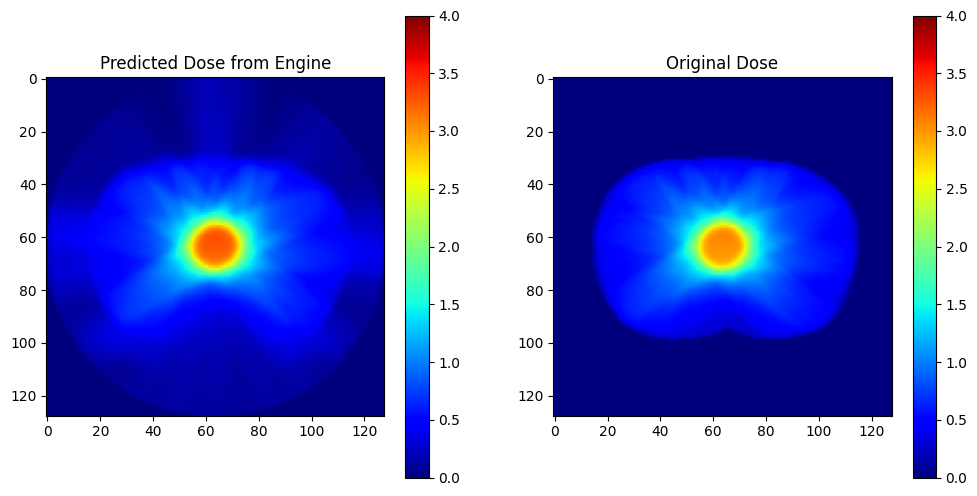

In [20]:
# Plot dose from engine and original dose
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(dose_pred[0, dose_pred.shape[1] // 2].cpu(), cmap="jet", vmin=0, vmax=4)
plt.title("Predicted Dose from Engine")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(dose[dose.shape[0] // 2], cmap="jet", vmin=0, vmax=4)
plt.title("Original Dose")
plt.colorbar()
plt.show()

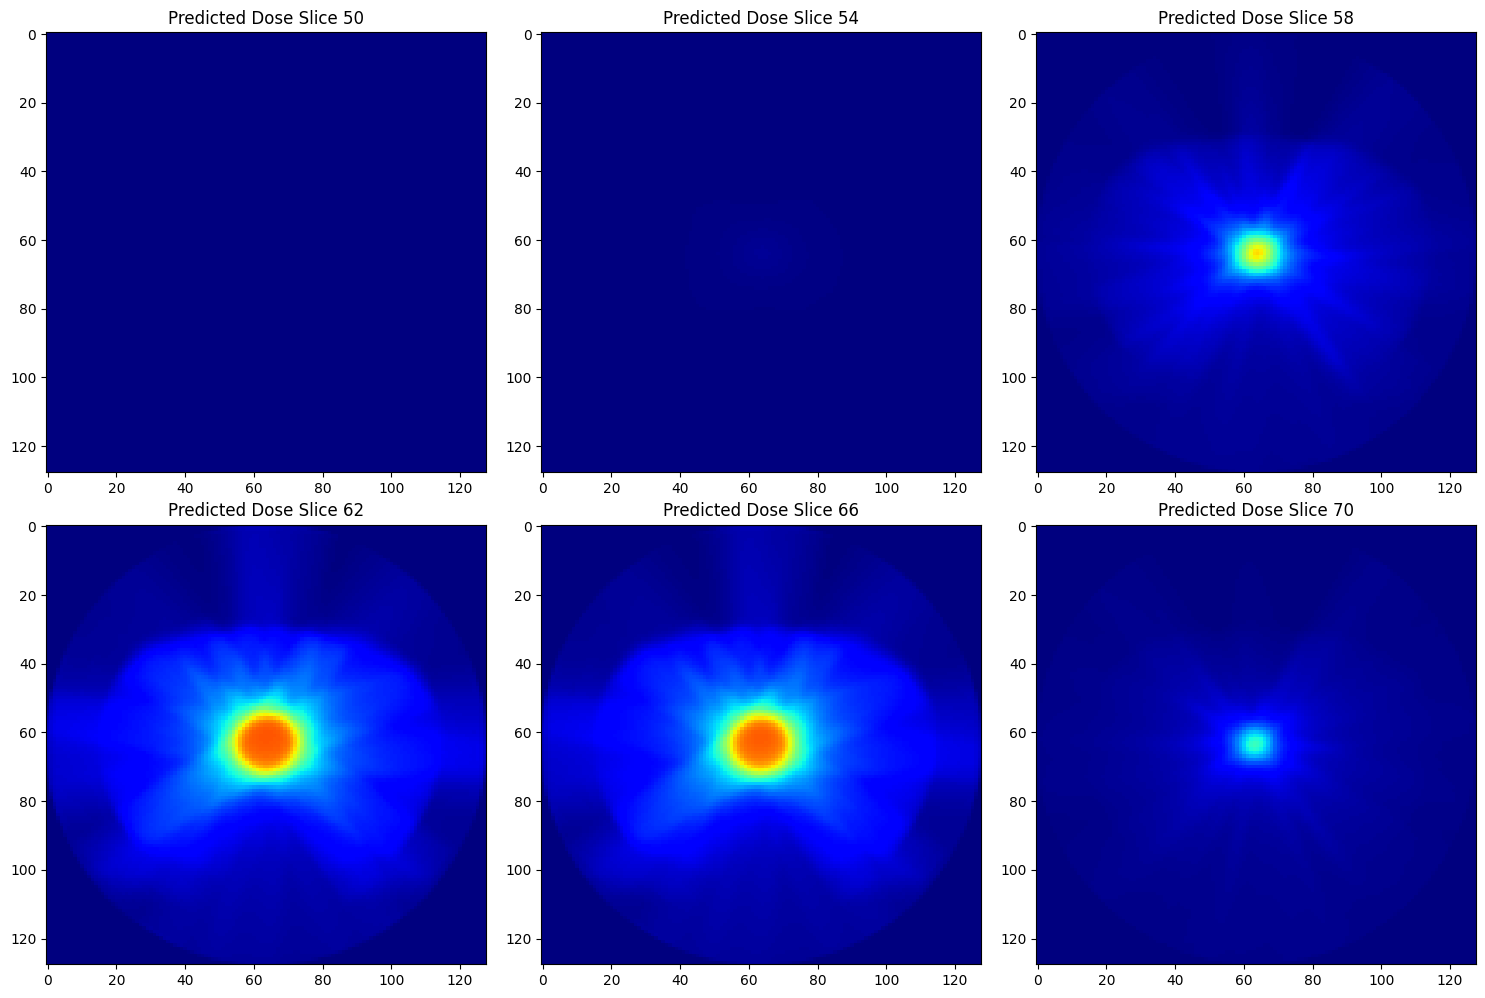

In [22]:
# Plot 6 slices of the predicted dose from 50 to 70

plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    slice_idx = 50 + i * (70 - 50) // 5
    plt.imshow(dose_pred[0, slice_idx].cpu(), cmap="jet", vmin=0, vmax=4)
    plt.title(f"Predicted Dose Slice {slice_idx}")
plt.tight_layout()
plt.show()